In [8]:
from collections import deque, namedtuple
import pandas as pd
import json
from tqdm import tqdm
import itertools
import numpy as np
import networkx as nx

In [9]:
results = {}

def pairwise(iterable):
    "s -> (s0,s1), (s1,s2), (s2, s3), ..."
    a, b = itertools.tee(iterable)
    next(b, None)
    return list(a), list(b)  
  
print("Running pathfinder AND route walker!")

Running pathfinder AND route walker!


In [18]:
graph = nx.Graph()
df = pd.read_csv("nodes_dist.csv")
#df = df.replace({'n1': interchange_codes, 'n2': interchange_codes})
df1 = pd.read_csv("stations.csv")
#df1 = df1.replace({'stn_code': interchange_codes})
df1 = df1.drop_duplicates()
df2 = pd.DataFrame()
for index, row in df.iterrows():
    graph.add_edge(row['n1'], row['n2'], weight=row['time'], net=row["network"])

In [19]:
print(df)

       n1    n2 inverse  time network Unnamed: 5
0     NS1   NS2       T   2.1    NSEW          3
1     NS2   NS3       T   1.2    NSEW          3
2     NS3   NS4       T   3.3    NSEW          3
3     NS4   NS5       T   1.4    NSEW        NaN
4     NS5   NS7       T   4.1    NSEW        NaN
..    ...   ...     ...   ...     ...        ...
240  EW13  NS25       T   0.0     INT           
241  EW14  NS26       T   0.0     INT        NaN
242  DT15   CC4       T   0.0     INT        NaN
243   STC  NE16       T   0.0     INT        NaN
244   PTC  NE17       T   0.0     INT        NaN

[245 rows x 6 columns]


In [30]:
#for index1, row1 in tqdm(df1['stn_code'].iteritems(), total = df1.size):
row1, row2 = "NS3", "EW22"
list1 = []
#for index2, row2 in df1['stn_code'].iteritems():
if row2 != row1:
  if row1 not in results:
    results[row1] = {};
  if row2 not in results[row1]:
    results[row1][row2] = []
  #results[row1][row2] = list(nx.dijkstra_path(graph, row1, row2))
  path = list(nx.dijkstra_path(graph, row1, row2))

nets_used = [graph.edges[ea[0], ea[1]]["net"] for ea in nx.path_graph(path).edges()]
print(nets_used)
nets = list(dict.fromkeys(nets_used).keys())
print(nets)

['NSEW', 'NSEW', 'INT', 'NSEW', 'NSEW']
['NSEW', 'INT']


In [45]:
import copy
new_graph = copy.deepcopy(graph)
for edge in graph.edges(data=True):
    if edge[2]["net"] == "INT":
        print(edge)
        new_graph = nx.contracted_edge(new_graph, (edge[0], edge[1]))
        new_graph.remove_edge(edge[0], edge[0])


('NS1', 'JE5', {'weight': 0.0, 'net': 'INT'})
('NS1', 'EW24', {'weight': 0.0, 'net': 'INT'})
('NS4', 'BP1', {'weight': 0.0, 'net': 'INT'})
('NS4', 'JS1', {'weight': 0.0, 'net': 'INT'})
('NS9', 'TE2', {'weight': 0.0, 'net': 'INT'})
('NS16', 'CR11', {'weight': 0.0, 'net': 'INT'})
('NS17', 'CC15', {'weight': 0.0, 'net': 'INT'})
('NS21', 'DT11', {'weight': 0.0, 'net': 'INT'})
('NS22', 'TE14', {'weight': 0.0, 'net': 'INT'})
('NS24', 'CC1', {'weight': 0.0, 'net': 'INT'})
('NS24', 'NE6', {'weight': 0.0, 'net': 'INT'})
('NS25', 'EW13', {'weight': 0.0, 'net': 'INT'})
('NS26', 'EW14', {'weight': 0.0, 'net': 'INT'})
('NS27', 'CE2', {'weight': 0.0, 'net': 'INT'})
('NS27', 'TE20', {'weight': 0.0, 'net': 'INT'})
('EW1', 'CR5', {'weight': 0.0, 'net': 'INT'})
('EW2', 'DT32', {'weight': 0.0, 'net': 'INT'})
('EW8', 'CC9', {'weight': 0.0, 'net': 'INT'})
('EW12', 'DT14', {'weight': 0.0, 'net': 'INT'})
('EW16', 'NE3', {'weight': 0.0, 'net': 'INT'})
('EW16', 'TE17', {'weight': 0.0, 'net': 'INT'})
('EW21', '

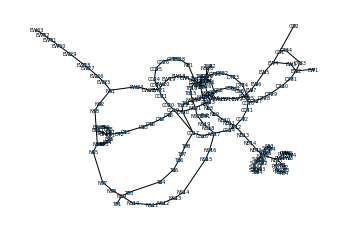

In [46]:
import matplotlib.pyplot as plt
pos = nx.kamada_kawai_layout(new_graph, scale=10)  # positions for all nodes

# nodes
nx.draw_networkx_nodes(new_graph, pos, node_size=5)

# edges
nx.draw_networkx_edges(new_graph, pos)

# labels
nx.draw_networkx_labels(new_graph, pos, font_size=5, font_family="sans-serif")

plt.axis("off")
plt.figure(1, figsize=(500,1000))
plt.savefig("graph_tel3_dist_ungraphed.png", dpi=500)